### **Imports and other prerequisites**

Importing necessary libraries, modules, and the Bates model class.

In [1]:
import json
import os
import warnings
warnings.filterwarnings('ignore')
import math
from math import erf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import Rbf
from BnS import BnS
from Bates import Bates

### **Initial configuration, Data recovery and validation**

Linking data files, setting up config parameters, and ensuring necessary datasets (including pre-calculated Vega) are available in memory.

In [2]:
DIVIDEND_YIELD = 0.0 # Assuming q=0 for GLD (Gold ETF)

# --- SAFETY CHECK: Restore variables from disk if missing from memory ---
if 'S0' not in globals():
    META_JSON_PATH = "Data/gld_chain_wide_meta.json"
    with open(META_JSON_PATH, "r", encoding="utf-8") as f:
        meta = json.load(f)
        for k in ["S0", "spot", "spot_price", "underlying_price", "underlying_last"]:
            if k in meta:
                S0 = float(meta[k])
                break
    print(f"[RECOVERY] Spot price (S0) restored from JSON: {S0:.2f}")

if 'dataset_chebyshev' not in globals():
    OUTPUT_CHEB_PATH = "Data/gld_iv_dataset_chebyshev.csv"
    if os.path.exists(OUTPUT_CHEB_PATH):
        dataset_chebyshev = pd.read_csv(OUTPUT_CHEB_PATH)
        print(f"[RECOVERY] 'dataset_chebyshev' loaded from disk: {len(dataset_chebyshev)} rows.")
    else:
        raise FileNotFoundError(f"Cannot find {OUTPUT_CHEB_PATH}. Please run the sampling cell in the previous notebook first.")

# Verify that Vega is present in the dataset (calculated in the previous phase)
if 'vega' not in dataset_chebyshev.columns:
    print("[INFO] Calculating Black-Scholes Vega for the dataset...")
    dataset_chebyshev['vega'] = dataset_chebyshev.apply(
        lambda row: BnS.calculate_bs_vega(
            S=S0, 
            K=row['K'], 
            T=row['T'], 
            r=row['rate'], 
            q=DIVIDEND_YIELD, 
            sigma=row['implied_vol']
        ), 
        axis=1
    )
    print("[SUCCESS] 'vega' column added!")

display(dataset_chebyshev.head())

[RECOVERY] Spot price (S0) restored from JSON: 437.82
[RECOVERY] 'dataset_chebyshev' loaded from disk: 64 rows.
[INFO] Calculating Black-Scholes Vega for the dataset...
[SUCCESS] 'vega' column added!


,expiry,T,K,price,rate,implied_vol,vega
0,2026-06-30,0.242596,358.0,87.52,0.037163,0.371853,39.893144
1,2026-06-30,0.242596,375.0,72.74,0.037163,0.354184,50.784943
2,2026-06-30,0.242596,395.0,56.57,0.037163,0.336587,64.543165
3,2026-06-30,0.242596,425.0,35.85,0.037163,0.316880,81.571765
4,2026-06-30,0.242596,455.0,20.77,0.037163,0.307369,85.422635


### **Bates Model Calibration and Vega-Weighting**

In the calibration of the Bates model, we expand the parameter space from 5 (Heston) to 8 to account for the Merton Jump-Diffusion process ($\lambda$, $\mu_J$, $\sigma_J$). 

We continue adopting a cost function based on Vega-weighting to efficiently approximate the Implied Volatility error. This approach ensures that all options, regardless of their moneyness and nominal premium, contribute equitably and mathematically correctly to the fitting of the complex volatility surface, especially the short-term Out-Of-The-Money options affected by the jump component.

**Model calibration execution**

In [3]:
# Running the optimization algorithms to find the best-fitting Bates parameters.
# Note: The 8-parameter optimization will take considerably longer than Heston.

optimal_params_bates = Bates.calibrate_bates(dataset_chebyshev, S0, q=DIVIDEND_YIELD)

[INFO] Starting Global Calibration for Bates (Differential Evolution)...
differential_evolution step 1: f(x)= 0.000394011376460678
differential_evolution step 2: f(x)= 0.000394011376460678
differential_evolution step 3: f(x)= 0.000394011376460678
differential_evolution step 4: f(x)= 0.000394011376460678
differential_evolution step 5: f(x)= 0.000394011376460678
differential_evolution step 6: f(x)= 0.000394011376460678
differential_evolution step 7: f(x)= 0.000394011376460678
differential_evolution step 8: f(x)= 0.000394011376460678
differential_evolution step 9: f(x)= 0.000394011376460678
differential_evolution step 10: f(x)= 0.000394011376460678
differential_evolution step 11: f(x)= 0.000394011376460678
differential_evolution step 12: f(x)= 0.000394011376460678
differential_evolution step 13: f(x)= 0.00029401679417056023
differential_evolution step 14: f(x)= 0.00029401679417056023
differential_evolution step 15: f(x)= 0.00029401679417056023
differential_evolution step 16: f(x)= 0.00029

### **Visualizations**

Generating Volatility Smile grids to compare Market IV against the theoretical Bates Model IV across different maturities.

[INFO] Generating Volatility Smile grid for Bates Model...


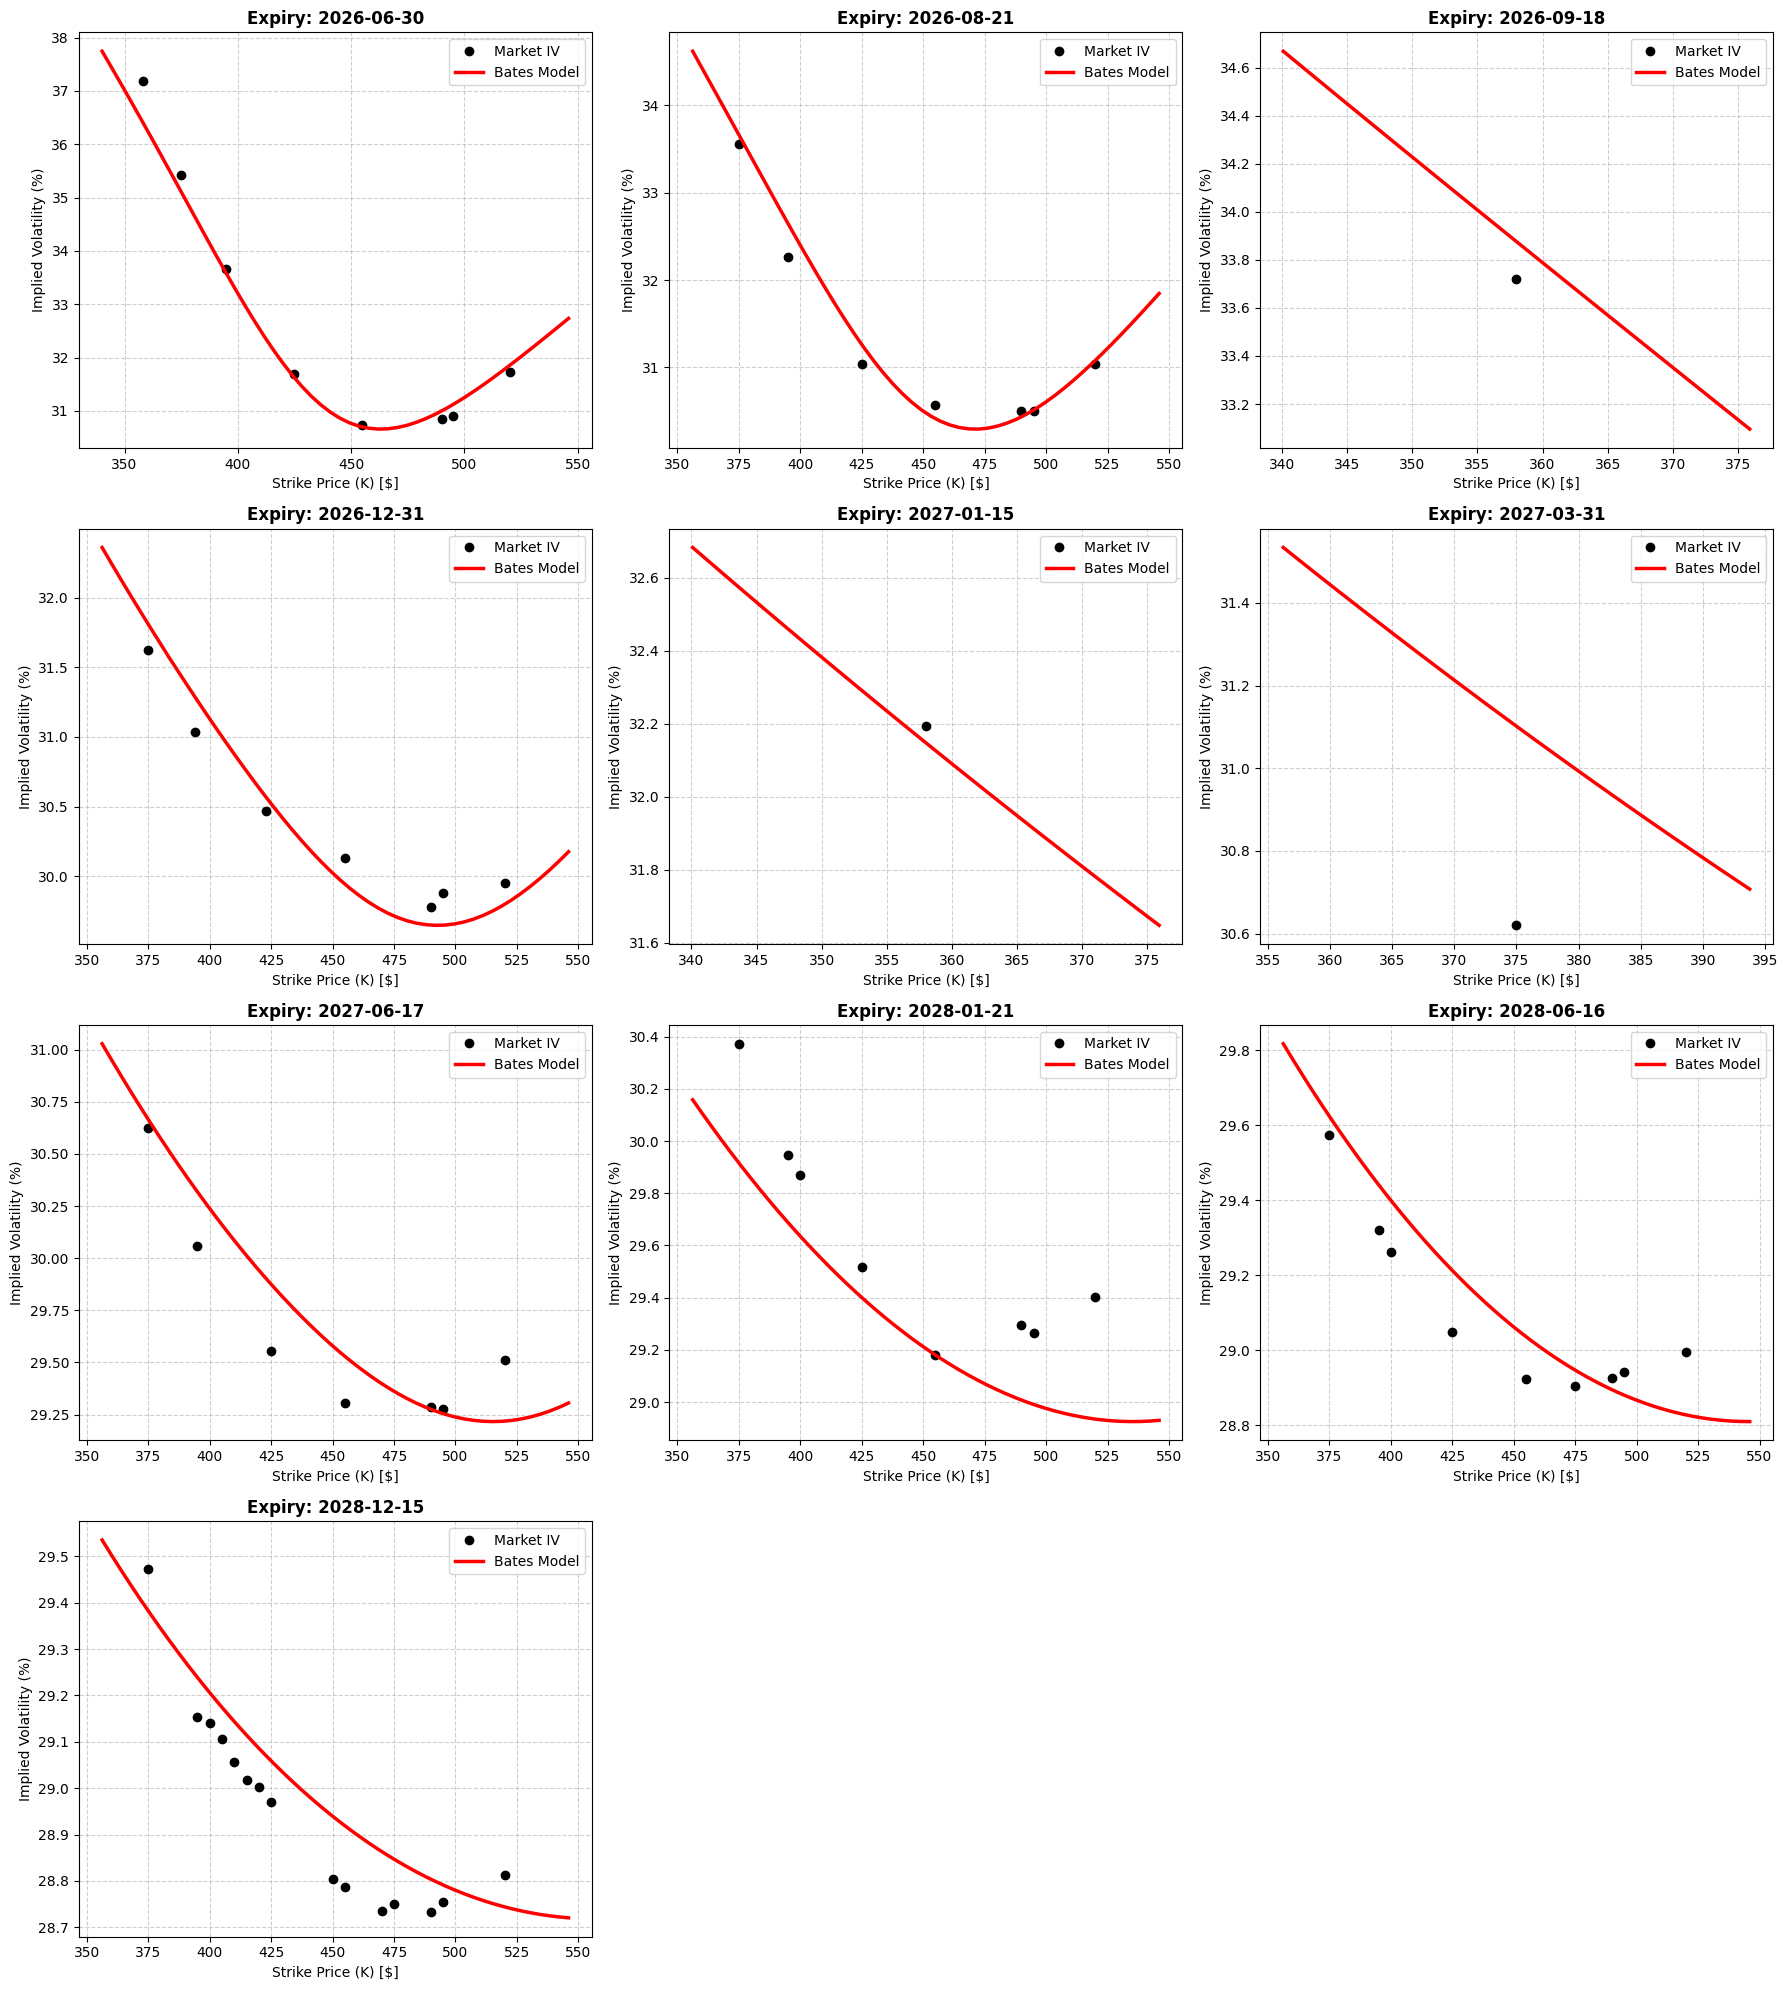

In [4]:
print("[INFO] Generating Volatility Smile grid for Bates Model...")

# Unpack your 8 optimized parameters
v0, kappa, theta, sigma, rho, lambd, mu_J, sigma_J = optimal_params_bates

maturities = sorted(dataset_chebyshev['T'].unique())

# --- OPTIONAL: EXCLUDE MATURITIES ---
exclude_maturities = [] 
maturities = [m for m in maturities if m not in exclude_maturities]
num_maturities = len(maturities)

# --- GRID CALCULATION ---
cols = min(3, num_maturities)
rows = math.ceil(num_maturities / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

if num_maturities == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

for i, T in enumerate(maturities):
    ax = axes[i]
    df_T = dataset_chebyshev[dataset_chebyshev['T'] == T]
    
    # Plot Market IV
    ax.plot(df_T['K'], df_T['implied_vol'] * 100, 'ko', markersize=6, label='Market IV')
    
    # Generate smooth theoretical Bates Curve
    K_min, K_max = df_T['K'].min(), df_T['K'].max()
    K_grid = np.linspace(K_min * 0.95, K_max * 1.05, 50)
    
    r = df_T['rate'].iloc[0] 
    q = DIVIDEND_YIELD
    
    bates_iv_curve = []
    
    for K in K_grid:
        # Calculate Theoretical Bates Price (using 8 parameters)
        b_price = Bates.bates_price_fast(S0, K, T, v0, kappa, theta, sigma, rho, lambd, mu_J, sigma_J, r, q)
        
        # Convert Bates Price back to IV
        b_iv = BnS.implied_vol_call(price=b_price, S=S0, K=K, T=T, r=r, q=q)
        
        if np.isnan(b_iv) or b_iv <= 0:
            bates_iv_curve.append(np.nan)
        else:
            bates_iv_curve.append(b_iv * 100)
            
    # Plot Bates Model IV
    ax.plot(K_grid, bates_iv_curve, 'r-', linewidth=2.5, label='Bates Model')
    
    # Formatting
    expiry_date = df_T['expiry'].iloc[0] if 'expiry' in df_T.columns else f"T={T:.2f}"
    ax.set_title(f'Expiry: {expiry_date}', fontweight='bold')
    ax.set_xlabel('Strike Price (K) [$]')
    ax.set_ylabel('Implied Volatility (%)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Data/bates_volatility_smile.png", dpi=300)
plt.show()

### **Residual Heatmap (Market vs. Bates)**

In this section, we analyze the residuals of the Bates Model. 
By projecting the difference between the Market IV and the Bates IV onto a Scatter-Heatmap (Time to Maturity vs. Moneyness), we can verify if the introduction of the Merton Jump-Diffusion process successfully absorbed the short-term mispricing observed in the pure diffusion model (Heston).

[INFO] Calculating Bates theoretical Implied Volatilities for residuals...
[INFO] Heatmap generation completed on 64 valid points...


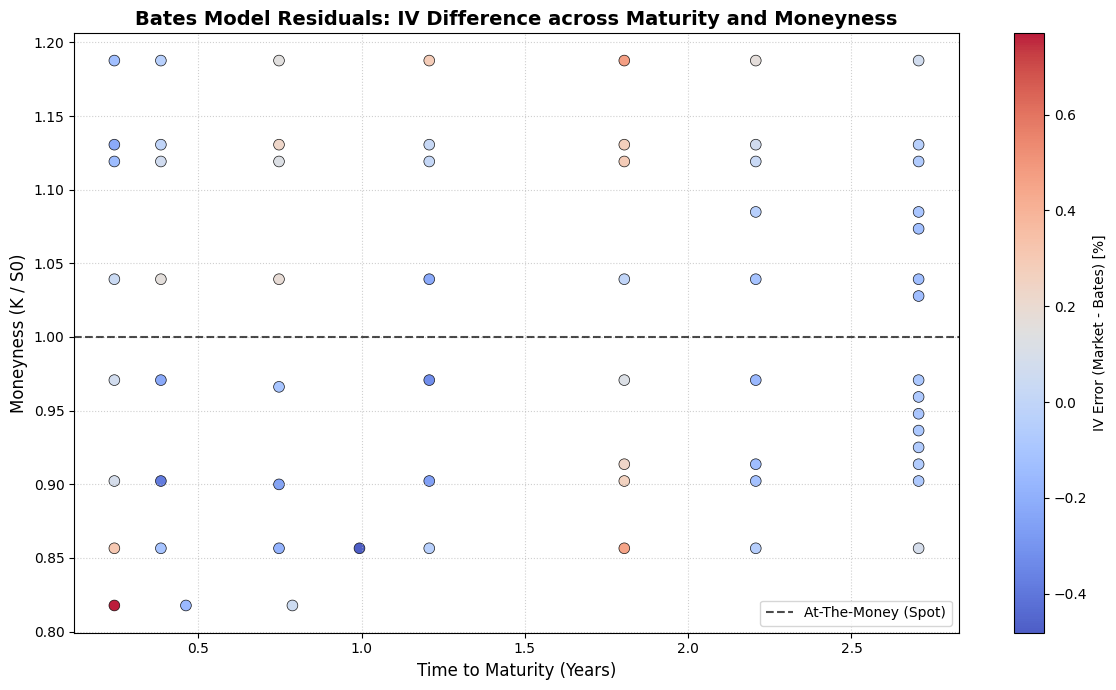

In [5]:
print("[INFO] Calculating Bates theoretical Implied Volatilities for residuals...")

v0, kappa, theta, sigma, rho, lambd, mu_J, sigma_J = optimal_params_bates
q = DIVIDEND_YIELD 

residuals_list = []

for _, row in dataset_chebyshev.iterrows():
    K = row['K']
    T = row['T']
    r = row['rate']
    market_iv = row['implied_vol']
    
    b_price = Bates.bates_price_fast(S0, K, T, v0, kappa, theta, sigma, rho, lambd, mu_J, sigma_J, r, q)
    b_iv = BnS.implied_vol_call(price=b_price, S=S0, K=K, T=T, r=r, q=q)
    
    if not np.isnan(b_iv) and b_iv > 0:
        moneyness = K / S0
        iv_residual = (market_iv - b_iv) * 100 
        residuals_list.append({
            'T': T, 
            'moneyness': moneyness, 
            'iv_residual': iv_residual
        })

df_residuals = pd.DataFrame(residuals_list)
print(f"[INFO] Heatmap generation completed on {len(df_residuals)} valid points...")

# --- CHART CREATION ---
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_residuals['T'], 
    df_residuals['moneyness'], 
    c=df_residuals['iv_residual'], 
    cmap='coolwarm', 
    s=60, 
    edgecolors='k', 
    linewidth=0.5,
    alpha=0.9
)

plt.colorbar(scatter, label='IV Error (Market - Bates) [%]')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='At-The-Money (Spot)')

plt.title('Bates Model Residuals: IV Difference across Maturity and Moneyness', fontsize=14, fontweight='bold')
plt.xlabel('Time to Maturity (Years)', fontsize=12)
plt.ylabel('Moneyness (K / S0)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("Data/bates_residual_heatmap.png", dpi=300)
plt.show()